<a href="https://colab.research.google.com/github/abdelrahman-rajab-hassan/data-analysis-lab/blob/main/projects/prediction-of-product-sales/Copy_of_prediction_of_product_sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Project: Prediction of Product Sales
- Auther: Abdelrahman R J Haasan

## Project Overview


## Load and Inspect Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# file path in my Google Drive
file_path = '/content/drive/MyDrive/data_science_projects/sales_predictions_2023.csv'

In [ ]:
# imported Pandas library
import pandas as pd
# the main DataFrame object
df = pd.read_csv(file_path)

In [ ]:
# data frame first five rows
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [ ]:
# the dataframe info()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


# Clean Data


In [ ]:
# describe shows us some important statistical summary
df.describe() # numeric dataset described before any cleaning or modification

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


# 1) How many rows and columns are there?

In [ ]:
'number of rows: ', len(df), 'number of columns: ', len(df.columns)

('number of rows: ', 8523, 'number of columns: ', 12)

# 2) What are the data type of each variable?

In [ ]:
# object columns
object_cols = df.select_dtypes('object').columns
# numerical columns
num_cols = df.select_dtypes('number').columns
# the below code shows the actual data type for each column. It's just to remove any confusion.
for cols in num_cols:
  print(df[cols].name)
  print(df[cols].dtype)
  print(' ')

Item_Weight
float64
 
Item_Visibility
float64
 
Item_MRP
float64
 
Outlet_Establishment_Year
int64
 
Item_Outlet_Sales
float64
 


# 3) Are there any duplicates? if so, drop any duplicates

In [ ]:
# duplicated rows
df.duplicated().sum()
# there are no duplicates at all.

np.int64(0)

# 4) Identify missing values

### There is a considerable amount of missing data in column Outlet_Size. Also, nearly one quarter of the values in the Item_Weight column are missing

In [ ]:
# num of missing data for each column
df.isna().sum()

,0
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


# 5) Adress the missing values by using a palceholder value

### For the numerical data in column Item_Weight, it's obvious that the mean and the median values are close. It shows that the distiribution is relatively symmetircal with minimal impact from outliers. So, we can use either mean or median as placeholder values in this case.

In [ ]:
df['Item_Weight'].describe()

,Item_Weight
count,7060.000000
mean,12.857645
std,4.643456
min,4.555000
25%,8.773750
50%,12.600000
75%,16.850000
max,21.350000


In [ ]:
# getting the mean of the Item_Weight column
tem_weight_mean = df['Item_Weight'].mean()

# fill the missing cells
df['Item_Weight'] = df['Item_Weight'].fillna(tem_weight_mean)

# re-check if null values are zero
print(df['Item_Weight'].isnull().sum())


0


### For the Outlet_Size column which is a categorical column, the missing values are filled with "Undefined" string.

In [ ]:
df['Outlet_Size'] = df['Outlet_Size'].fillna("Undefined")
df['Outlet_Size'].isna().sum()

np.int64(0)

# 6) Confirm that there is no missing data after addrissing them.

In [ ]:
df.isna().sum()

,0
Item_Identifier,0
Item_Weight,0
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,0
Outlet_Location_Type,0


# 7) Find and fix any inconsistent categories of data (for example: fix cat, Cat, and cats so that they are consistent




In [ ]:
# show the categorical data first
cat_columns = df.select_dtypes("object").columns

In [ ]:
# show Item_Fat_Content values
df['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
Low Fat,5089
Regular,2889
LF,316
reg,117
low fat,112


In [ ]:
# replace LF and low fat with Low Fat, and reg with Regular
df['Item_Fat_Content'] = df['Item_Fat_Content'].replace({
    'LF': 'Low Fat',
    'low fat': 'Low Fat',
    'reg': 'Regular'
})

In [ ]:
# show Item_Fat_Content values after fixing the values
df['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
Low Fat,5517
Regular,3006


# 8) For any numerical columns obtain the summary stas

In [ ]:
# display the stats of each numerical column
df.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,8523.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.226124,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,9.310000,0.026989,93.826500,1987.000000,834.247400
50%,12.857645,0.053931,143.012800,1999.000000,1794.331000
75%,16.000000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


In [ ]:
df.head(10)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.300000,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.920000,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.500000,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.200000,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,Undefined,Tier 3,Grocery Store,732.3800
4,NCD19,8.930000,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052
5,FDP36,10.395000,Regular,0.000000,Baking Goods,51.4008,OUT018,2009,Medium,Tier 3,Supermarket Type2,556.6088
6,FDO10,13.650000,Regular,0.012741,Snack Foods,57.6588,OUT013,1987,High,Tier 3,Supermarket Type1,343.5528
7,FDP10,12.857645,Low Fat,0.127470,Snack Foods,107.7622,OUT027,1985,Medium,Tier 3,Supermarket Type3,4022.7636
8,FDH17,16.200000,Regular,0.016687,Frozen Foods,96.9726,OUT045,2002,Undefined,Tier 2,Supermarket Type1,1076.5986
9,FDU28,19.200000,Regular,0.094450,Frozen Foods,187.8214,OUT017,2007,Undefined,Tier 2,Supermarket Type1,4710.5350


## Exploratory Data Analysis



In [ ]:
df.select_dtypes('number').columns

Index(['Item_Weight', 'Item_Visibility', 'Item_MRP',
       'Outlet_Establishment_Year', 'Item_Outlet_Sales'],
      dtype='object')

In [ ]:
df['Item_Weight'].value_counts(bins = 10, sort = True)

,count
"(11.273, 12.952]",2242
"(6.234, 7.914]",870
"(7.914, 9.594]",865
"(14.632, 16.312]",755
"(16.312, 17.991]",735
"(17.991, 19.671]",677
"(9.594, 11.273]",664
"(12.952, 14.632]",629
"(19.671, 21.35]",603
"(4.537, 6.234]",483


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

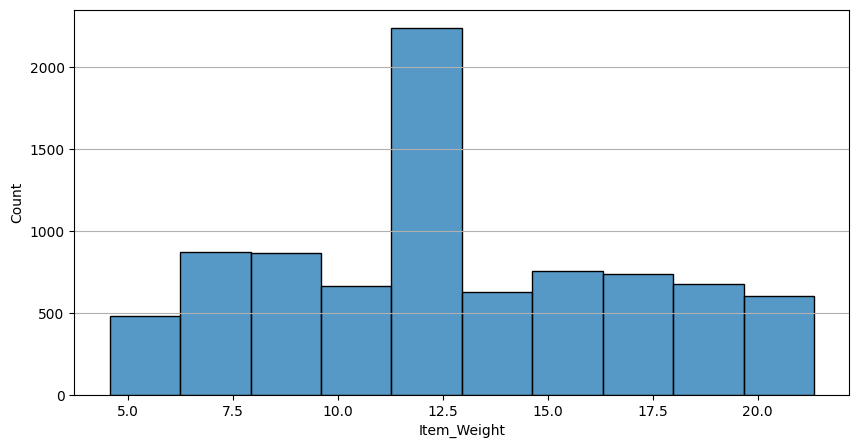

In [ ]:
# Item_weight histogram
figure, ax = plt.subplots( figsize = (10, 5) )

sns.histplot(data = df, x = 'Item_Weight', bins = 10)
plt.grid(axis = 'y')

The Item_Weight histogram shows a relatively uniform distribution across most weight classes. However, there is a significant spike in frequency for items weighing between approximately 11.2 and 13, which represents the most common weight range in the dataset.

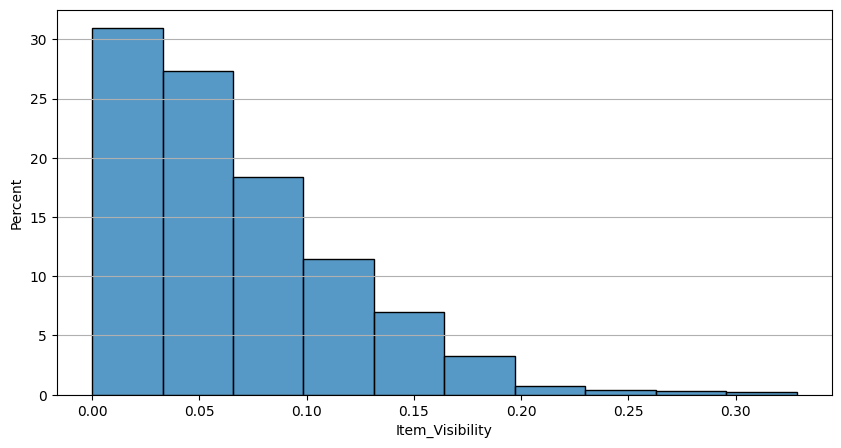

In [ ]:
# Item_Visibility histogram
figure, ax = plt.subplots( figsize = (10, 5) )
sns.histplot(data = df, x = 'Item_Visibility', bins = 10, stat='percent')
plt.grid(axis = 'y')

The Item_Visibility histogram displays an asymmetrical, right-skewed distribution. A significant majority of the data—roughly 60%—is concentrated within the range of 0.0 to 0.09, while the frequency steadily tapers off as visibility increases.

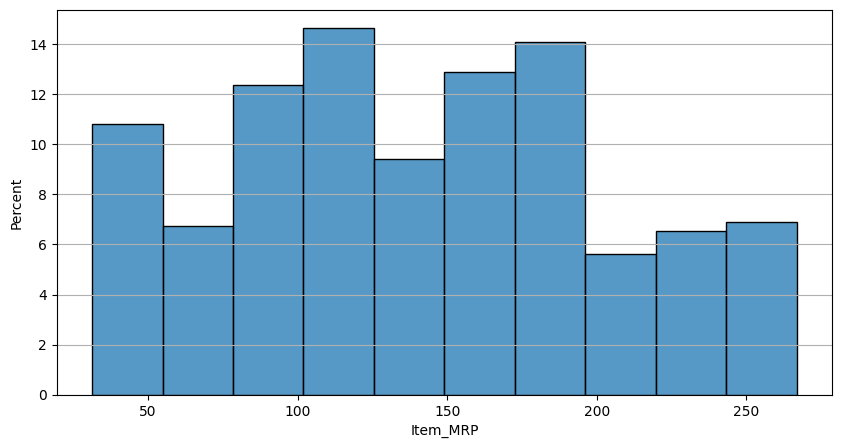

In [ ]:
# Item_MRP histogram
figure, ax = plt.subplots( figsize = (10, 5) )
sns.histplot(data = df, x = 'Item_MRP', bins = 10, stat='percent')
plt.grid(axis = 'y')

The Item_MRP histogram depicts a multimodal distribution with several distinct peaks. Approximately two-thirds of the data is concentrated within the price range of 70 to 200, while the overall spread indicates significant price variation across the dataset.

<!-- The Item_MRP histogram depicts a roughly uniform ditribution with almost two-thirds of the data concentrate within 70 to 200.-->

## Featuer inspection


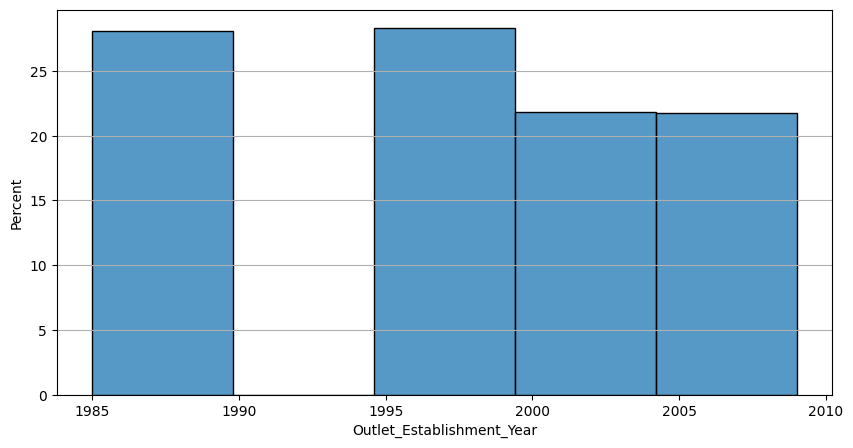

In [ ]:
# Item_Outlet_Establishment_Year histogram
figure, ax = plt.subplots( figsize = (10, 5) )
sns.histplot(data = df, x = 'Outlet_Establishment_Year', bins = 5, stat='percent')
plt.grid(axis = 'y')

The data is somewhat evenly distributed across years with a clear gap around 1990–1994

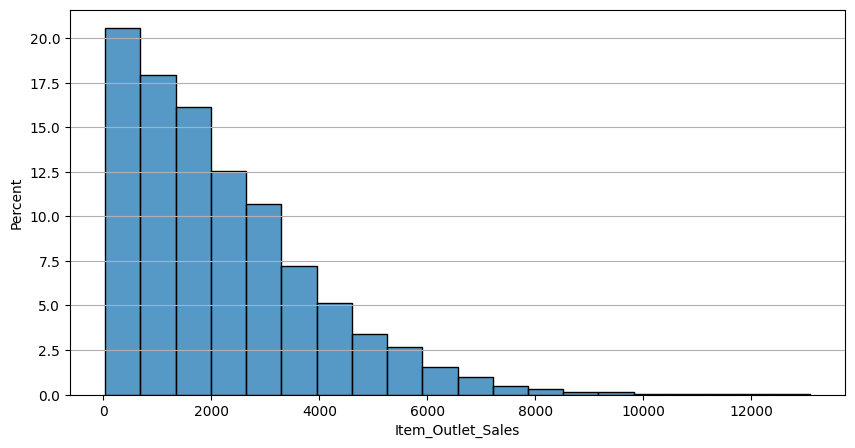

In [ ]:
# Item_Outlet_Sales histogram
figure, ax = plt.subplots( figsize = (10, 5) )
sns.histplot(data = df, x = 'Item_Outlet_Sales', bins = 20, stat='percent')
plt.grid(axis = 'y')

The Item_Outlet_Sales histogram depicts a right-skewed distribution, where approximately two-thirds of the data points fall below a value of 4,000. The frequency steadily declines as sales figures increase, indicating a long tail toward higher revenue values.

<!-- The Item_outlet_Sales plot/figure/histogram shows/displays/depicts a right-skewed ditribution with approximately two-thirds of data are less than 4000. -->

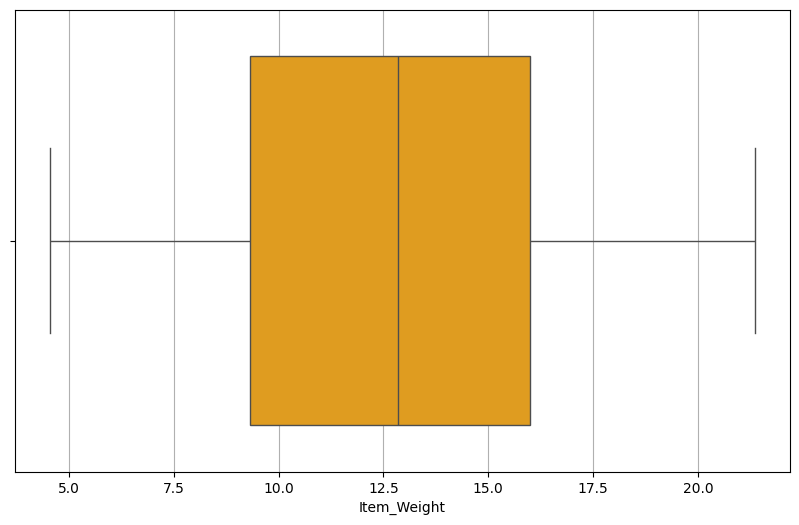

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(data = df, x = 'Item_Weight', color = 'orange');
plt.grid(axis = 'x')


The Item_Weight box plot illustrates that the interquartile range (IQR)—containing the middle 50% of the data—spans from approximately 9 to 16. The distribution appears relatively symmetrical with a median near 13, and the absence of individual points beyond the whiskers indicates there are no outliers in this feature.

<!-- The Item_Weight box plot demonstrates around 50% of the data lies between 9 and 16 with no outliers in the set. -->

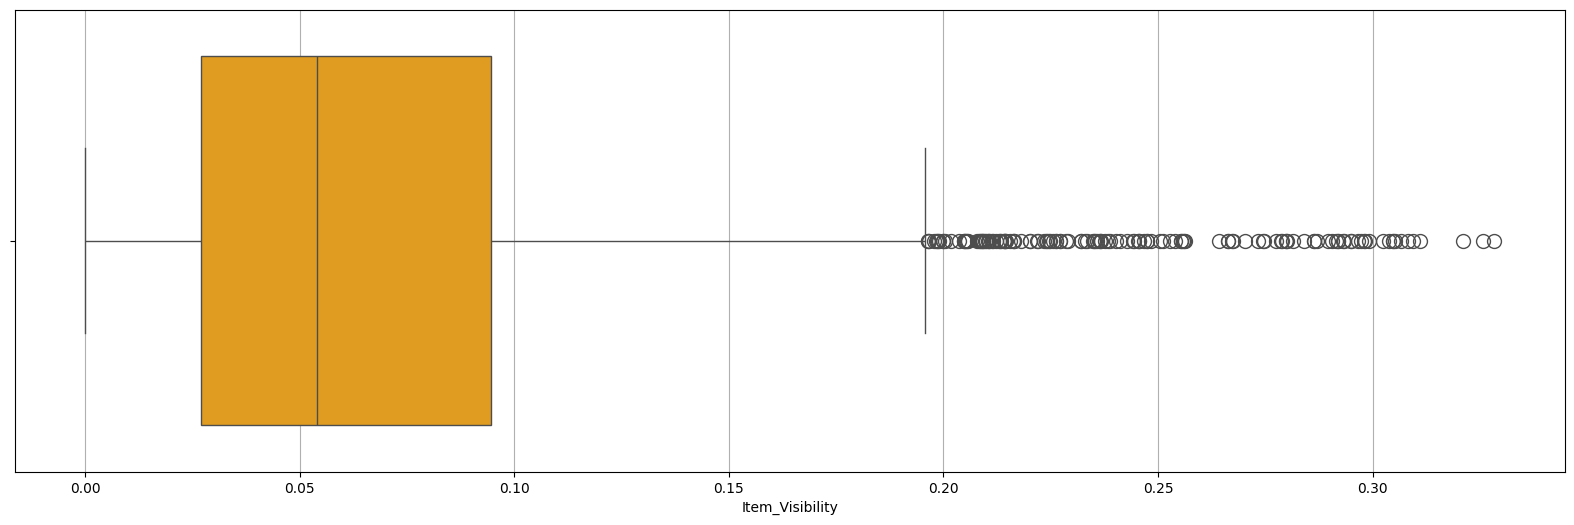

In [ ]:
plt.figure(figsize=(20,6))
sns.boxplot(data = df, x = 'Item_Visibility', flierprops={'markersize': 10}, color = 'orange');
plt.grid(axis = 'x')

The Item_Visibility box plot illustrates that the middle 50% of the data falls between approximately 0.03 and 0.09, with the median centered around 0.055. The high number of individual points beyond the right whisker indicates a significant presence of outliers, highlighting a right-skewed distribution

<!-- The Item_Visibility figure illustrates that half of the data falls between 0.03 and 0.09 with the median around 0.055. The high numer of dots beyond the right whisker indicates that there high number of outliers in the set. -->

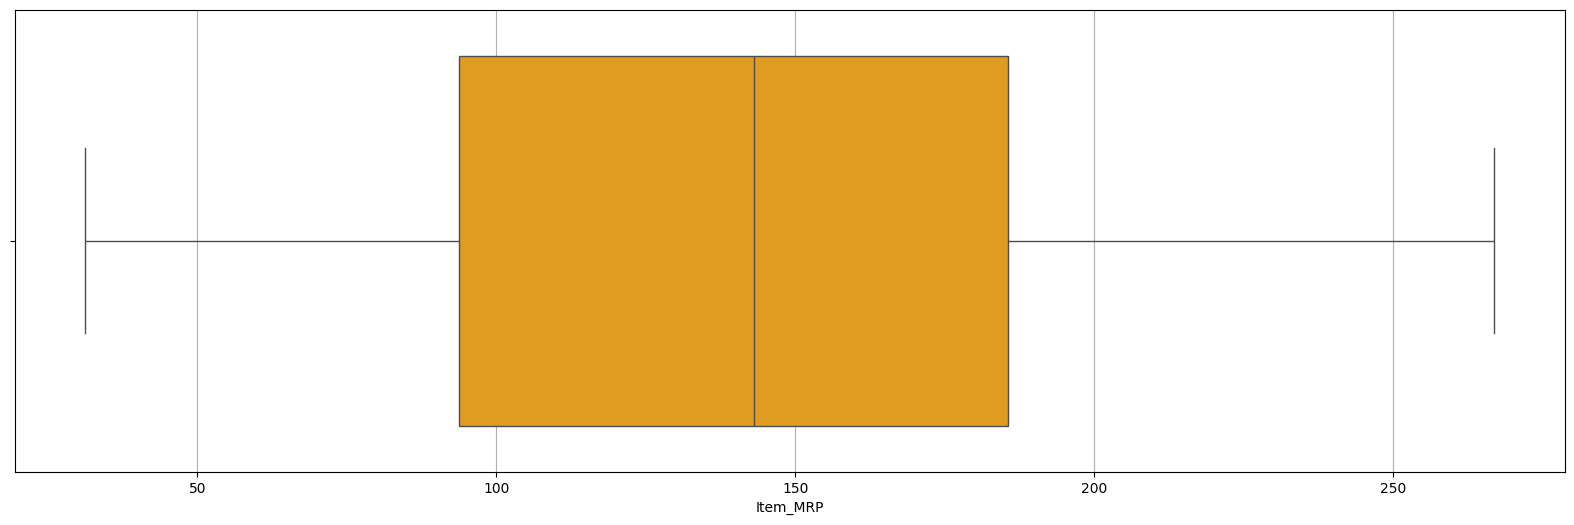

In [ ]:
plt.figure(figsize=(20,6))
sns.boxplot(data = df, x = 'Item_MRP', flierprops={'markersize': 10}, color = 'orange');
plt.grid(axis = 'x')

The Item_MRP box plot illustrates that the middle 50% of the entries fall between approximately 90 and 175. The median is centered near 143, and the distribution is free of outliers, as indicated by the absence of individual data points beyond the whiskers.


<!-- The box plot of Item_MRP entries shows that the middle 50% of the data falls between 90 and 170 with the median centered around 145 and no outliers are indicated -->

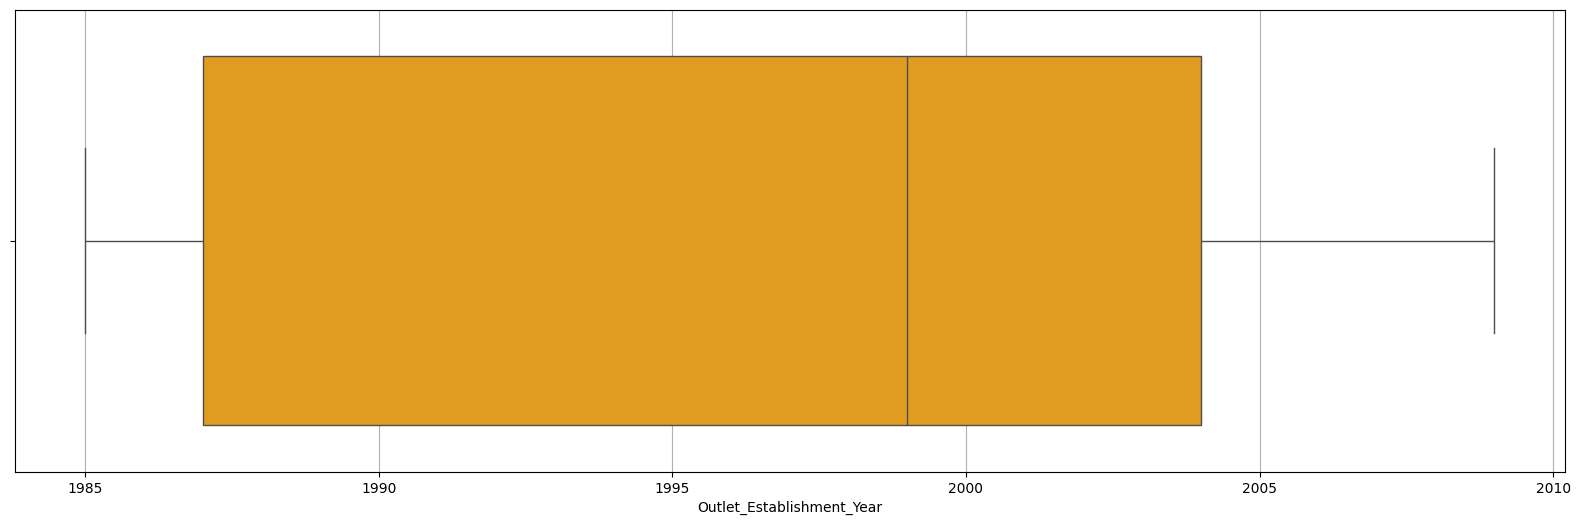

In [ ]:
plt.figure(figsize=(20,6))
sns.boxplot(data = df, x = 'Outlet_Establishment_Year', flierprops={'markersize': 10}, color = 'orange');
plt.grid(axis = 'x')

The Outlet_Establishment_Year box plot illustrates that the interquartile range (IQR)—representing the middle 50% of the data—spans from approximately 1987 to 2004. The median is centered near 1999, and the distribution is devoid of outliers, as evidenced by the absence of individual data points beyond the whiskers

<!-- The Outlet_Establishment_Year box illustrates that the middle 50% of data lies approximately between 1987 and 2004 with the median is centered close to 1998 and the distribution is free of outliers as there is no single data points beyond the whiskers.  -->

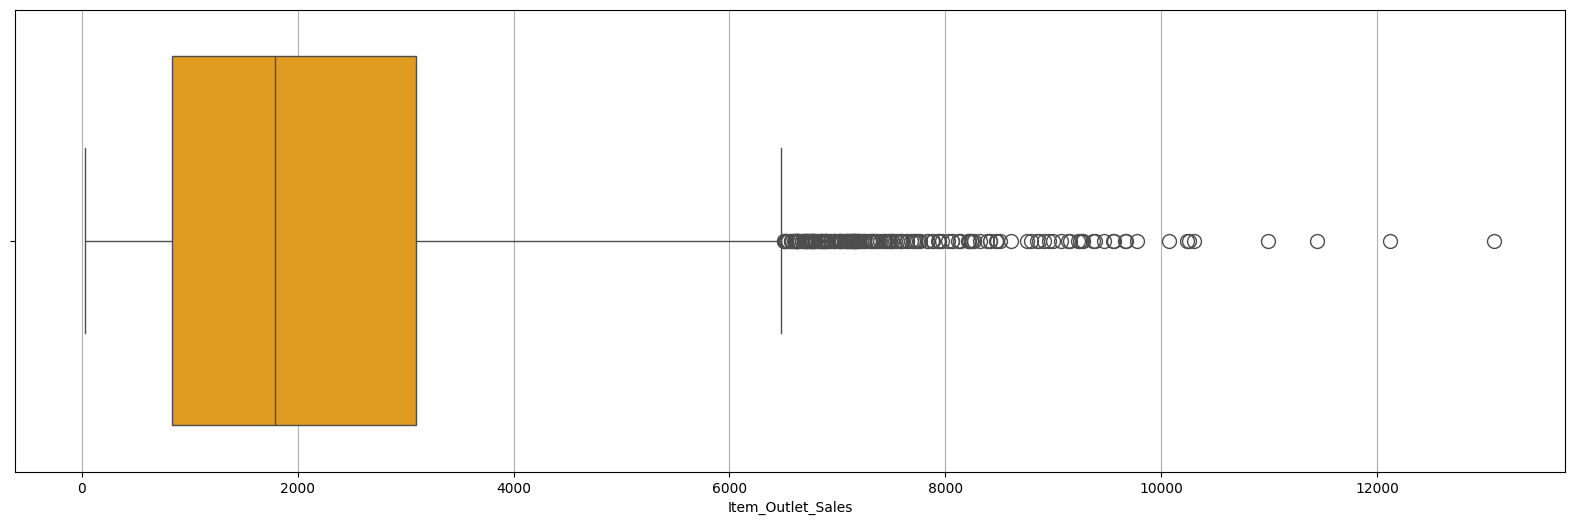

In [ ]:
plt.figure(figsize=(20,6))
sns.boxplot(data = df, x = 'Item_Outlet_Sales', flierprops={'markersize': 10}, color = 'orange');
plt.grid(axis = 'x')

The Item_Outlet_Sales box plot reveals a heavily right-skewed distribution, characterized by a substantial number of outliers extending beyond the upper whisker. The interquartile range (IQR) indicates that the middle 50% of the data is concentrated between approximately 1,000 and 3,100, with a median value slightly below 2,000.

<!-- The Item_Outlet_Sales box plot shows a right-skewed distirbution of data as indicated by the large number of outliers beyond the right whisker, and nearly 50% of the data is concentrated between 1000 and 3000.  -->

In [ ]:
# Categorical columns
objects = df.select_dtypes('object').columns
objects

Index(['Item_Identifier', 'Item_Fat_Content', 'Item_Type', 'Outlet_Identifier',
       'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type'],
      dtype='object')

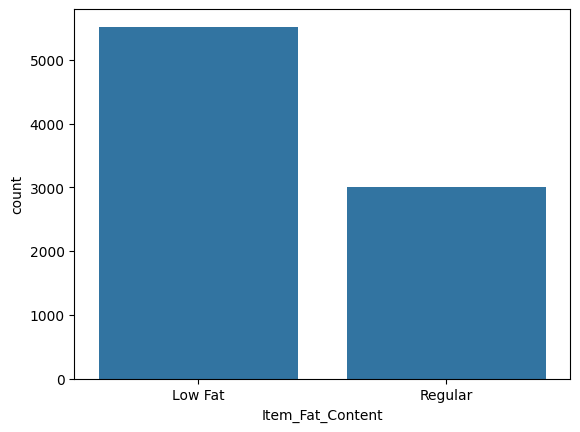

In [ ]:
# Item_Identifier fequency table
sns.countplot(data = df, x = 'Item_Fat_Content');

The count plot for Item_Fat_Content reveals that the frequency of 'Low Fat' products is nearly double that of 'Regular' items.

<!-- The number of low fat items is approximatel double the regular items.  -->

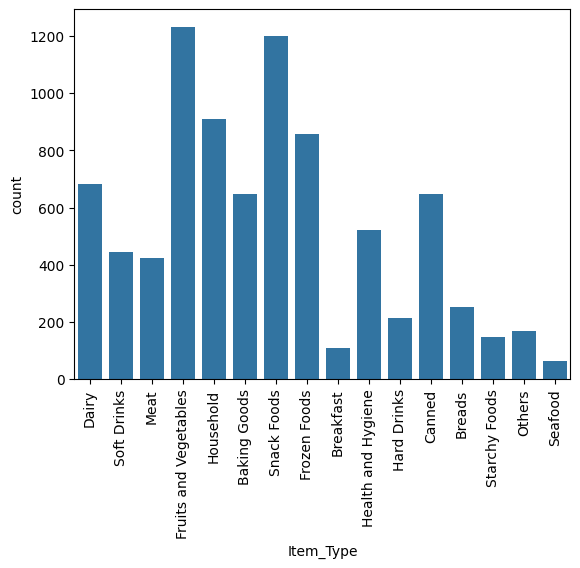

In [ ]:
sns.countplot(data = df, x = 'Item_Type')
plt.tick_params(axis = 'x', rotation = 90);

The count plot shows that Fruits & Vegetables has the highest number of items, followed by Snack Foods and Household. In contrast, categories like Seafood and Breakfast have the lowest counts

<!-- The count plot displays a high number of items with fruits and vegetables, frozen food and household categories, respectively. It also shows a lower frequency for seafood and breakfast categories.  -->

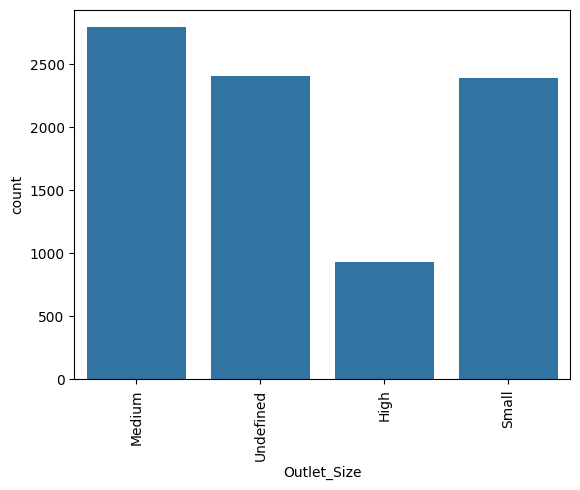

In [ ]:
# Outlet_size type

sns.countplot(data = df, x = 'Outlet_Size')
plt.tick_params(axis = 'x', rotation = 90);

The count plot shows that Medium outlet sizes are the most common, while High outlet sizes have the lowest frequency. Additionally, there is a considerable number of Undefined entries, indicating missing or unspecified data.

<!--
strong phrasing
Medium-sized outlets dominate the dataset, whereas High-sized outlets are underrepresented. The presence of a large number of Undefined values suggests potential data quality issues that may require preprocessing
 -->

<!-- The higest frequecny of all sizes is medium. There is a significant number of unknown sizes items. High sizes are the has the lowest frequency.  -->

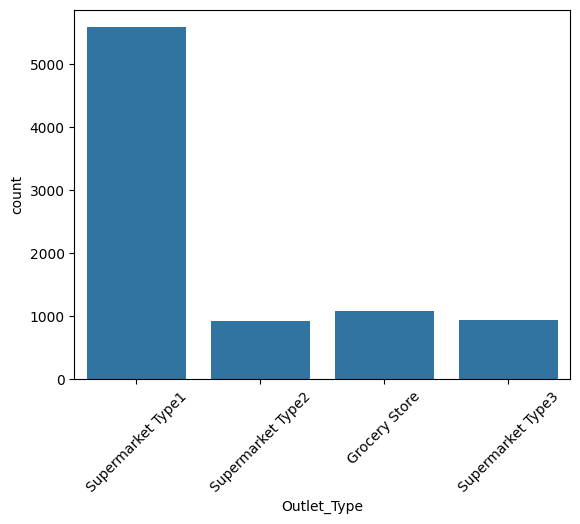

In [ ]:
# Outlet_size type

sns.countplot(data = df, x = 'Outlet_Type')
plt.tick_params(axis = 'x', rotation = 45);

The count plot displays that Supermarket type1 dominates the dataset, whereas Supermarket type 2 has the lowest frequncy.

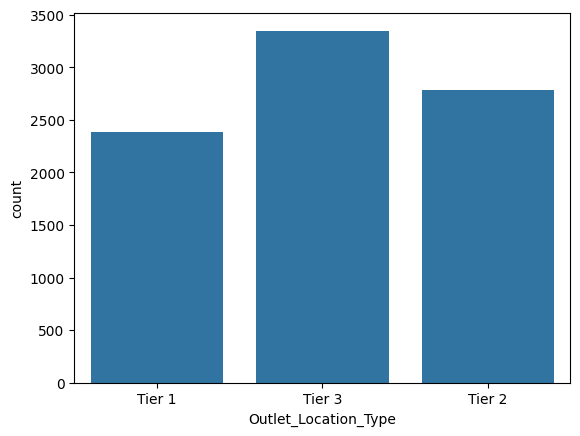

In [ ]:
# Outlet_size type

sns.countplot(data = df, x = 'Outlet_Location_Type')
plt.tick_params(axis = 'x');

The count plot shows that Tier 3 locations have the highest number of outlets, followed by Tier 2, while Tier 1 has the lowest count.

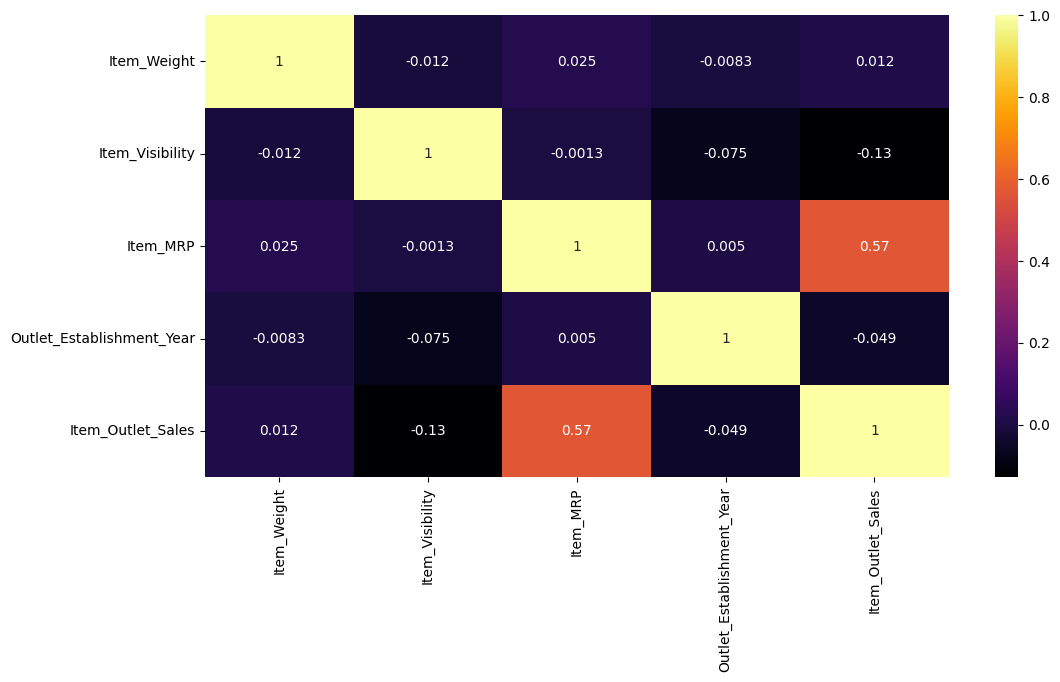

In [ ]:
plt.figure(figsize=(12,6))
sns.heatmap(df.corr(numeric_only = True), cmap = 'inferno', annot = True);

The heatmap shows that most variables have weak correlations with each other. However, there is a moderate positive correlation between Item_MRP and Item_Outlet_Sales (~0.57). Additionally, Item_Visibility has a slight negative correlation with sales

<!--
Strong phrasing

Most features show little to no linear relationship, indicating low multicollinearity. However, Item_MRP has a moderate positive correlation with Item_Outlet_Sales, suggesting that higher-priced items tend to generate higher sales. In contrast, Item_Visibility shows a weak negative relationship with sales
 -->

## Feature Inspection
